# Quality control and standard processing of the 78-sample AL cohort

**Biology rationale.** Reliable biological comparisons require removal of low-quality cells, ambient RNA, and doublets before integration and annotation.

**Aim.** Generate a quality-controlled, normalized, and integrated single-cell object for downstream analyses.

**Data input.**  `./250817-AL-all78umap-singletonly-umap.rds`, `250817-AL-all78umap-singletonly-umap.h5ad`

**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DoubletFinder)
library(SoupX)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1 <- readRDS(file='./250817-AL-all78umap-singletonly-umap.rds')

In [3]:
sce1 <- FindNeighbors(sce1, dims = 1:20, reduction = "pca")
sce1 <- FindClusters(sce1, resolution = 2, cluster.name = "seurat_clusters")

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 630111
Number of edges: 17421735

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9266
Number of communities: 88
Elapsed time: 372 seconds


1 singletons identified. 87 final clusters.



In [4]:
sce1 <- RunUMAP(sce1, dims = 1:20, reduction = "pca", reduction.name = "UMAP")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:05:00 UMAP embedding parameters a = 0.9922 b = 1.112

10:05:00 Read 630111 rows and found 20 numeric columns

10:05:00 Using Annoy for neighbor search, n_neighbors = 30

10:05:00 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:05:55 Writing NN index file to temp file /tmp/RtmpLaoVLW/file3e2f526d8878bb

10:05:55 Searching Annoy index using 1 thread, search_k = 3000

10:10:24 Annoy recall = 100%

10:10:26 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbo

scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



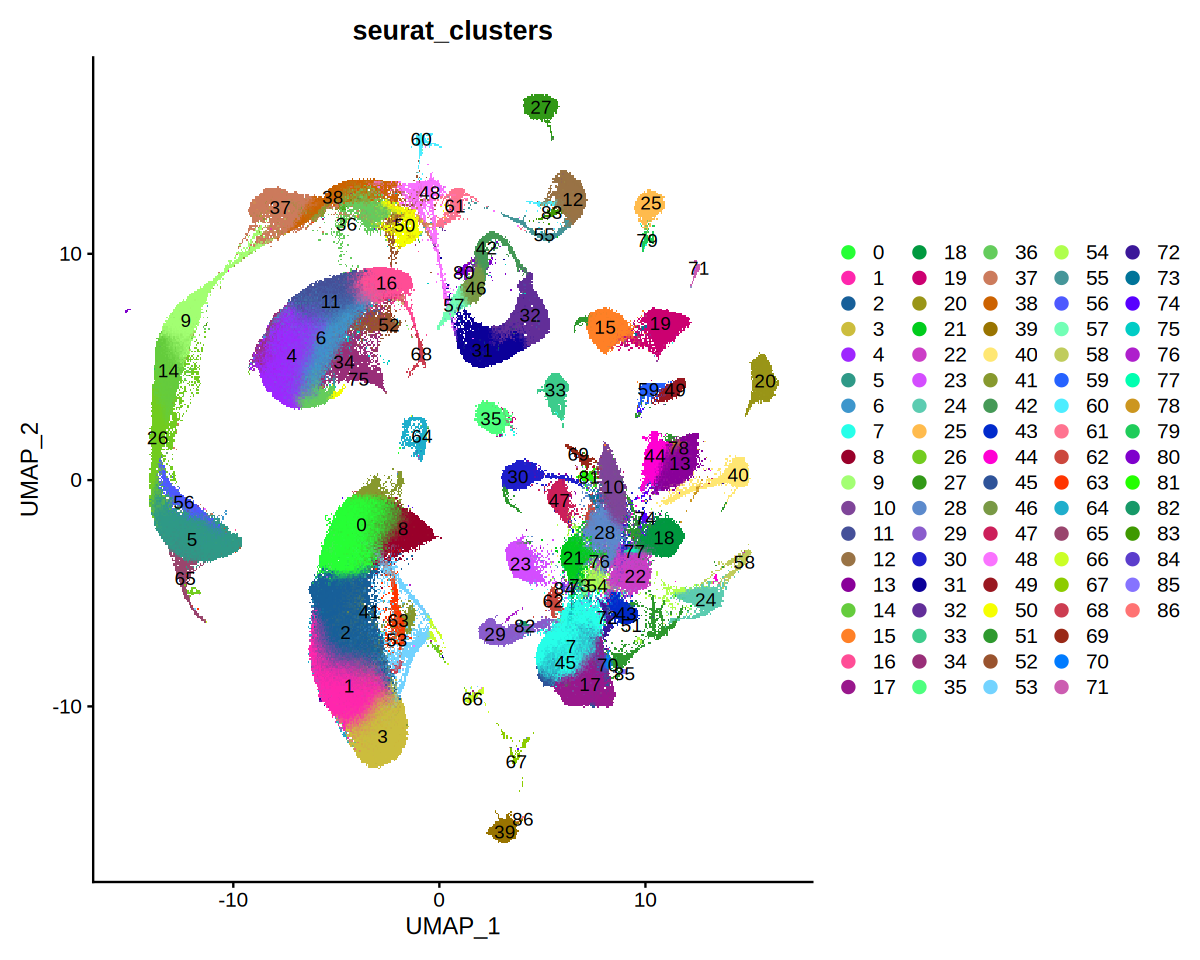

In [5]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("seurat_clusters"),label=T) 

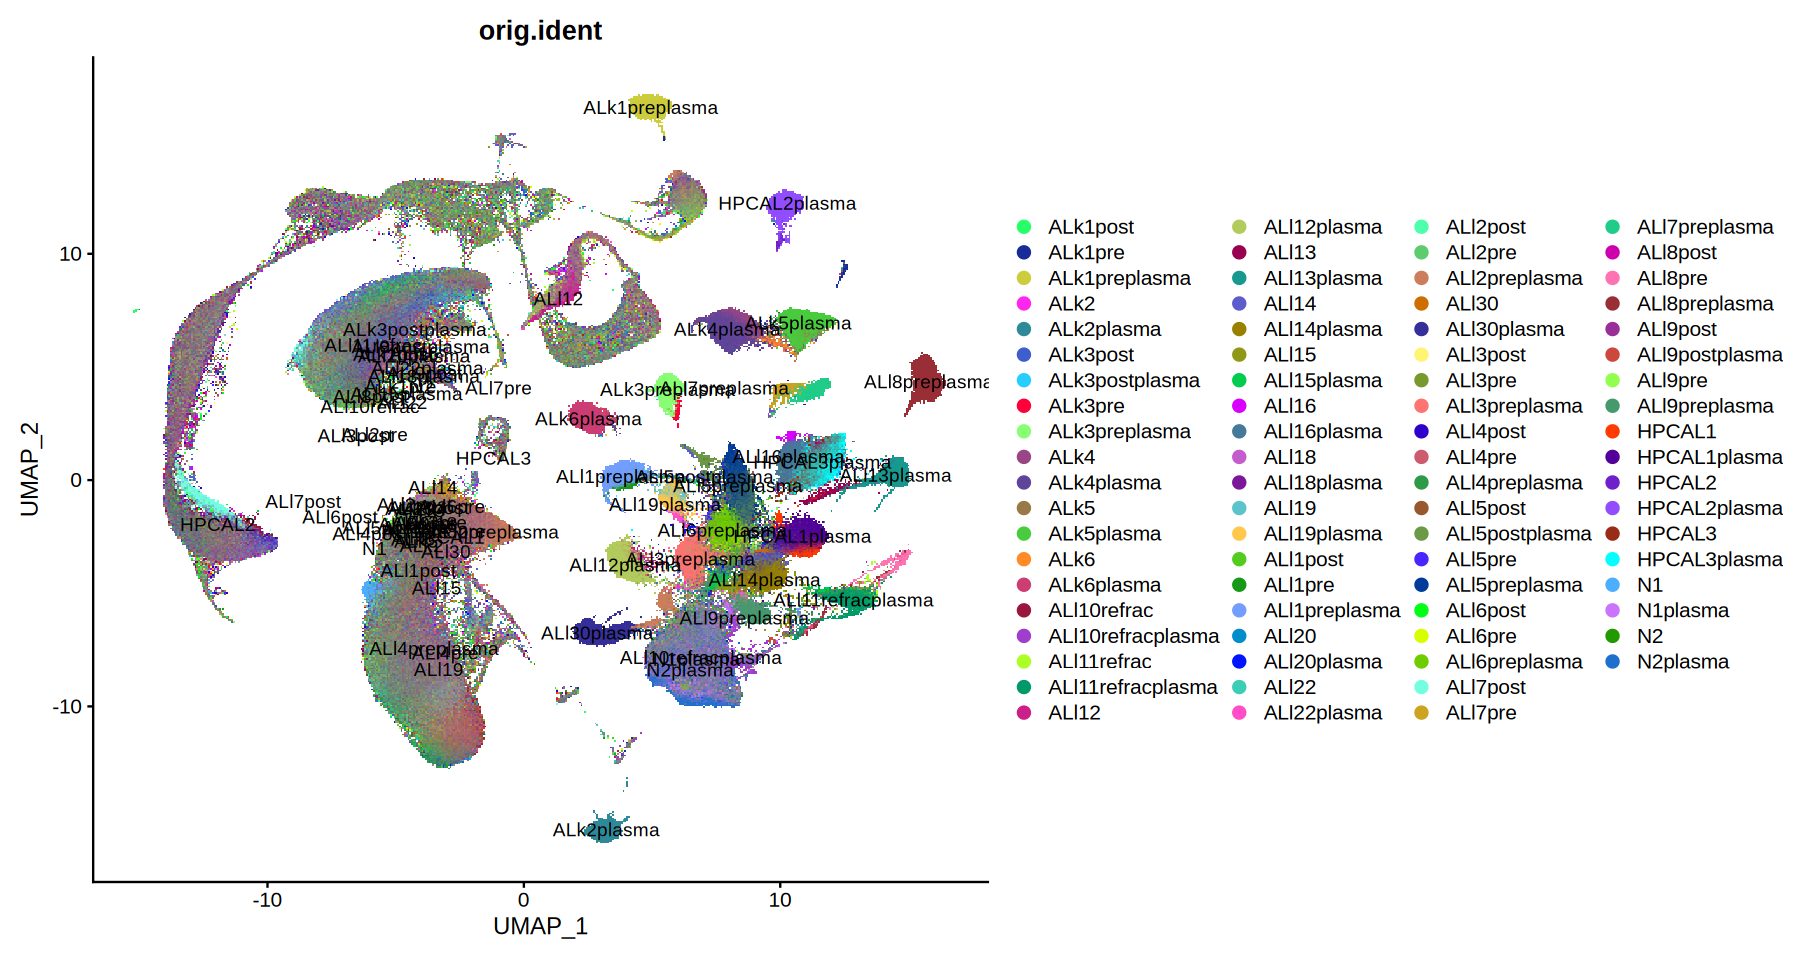

In [6]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("orig.ident"),label=T) 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



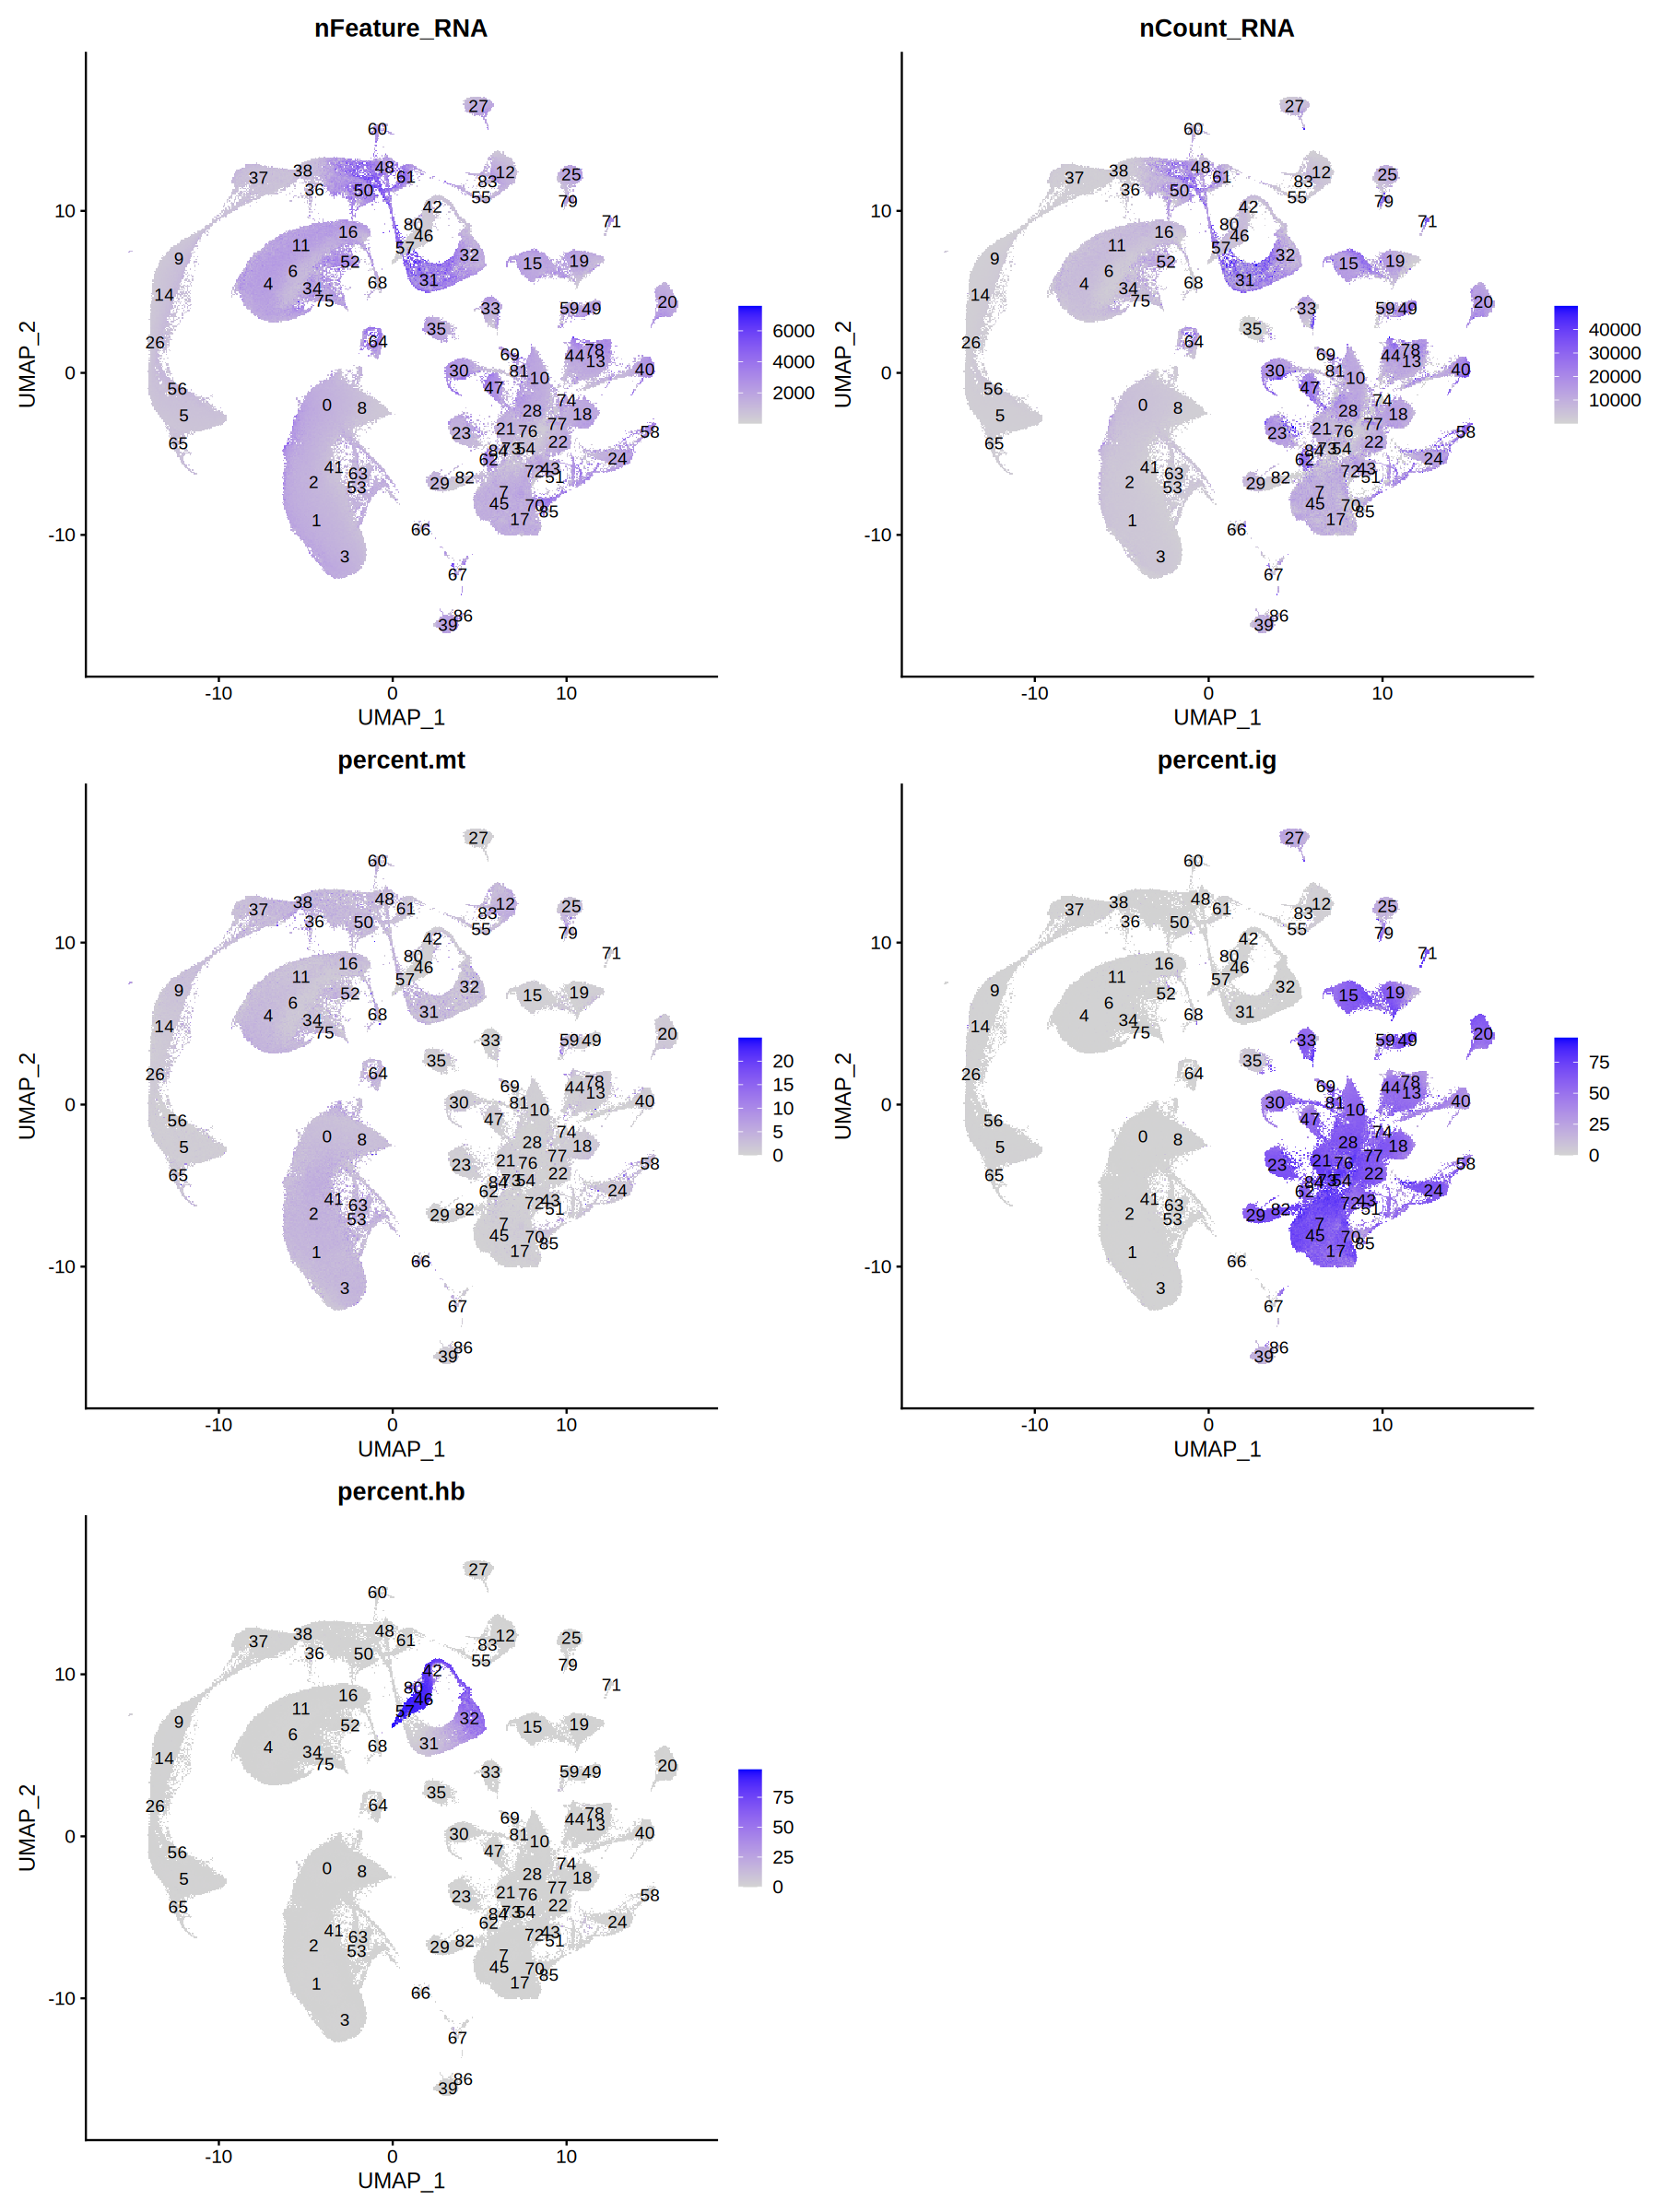

In [7]:
library('RColorBrewer')
options(repr.plot.height=20,repr.plot.width=15)
FeaturePlot(sce1, pt.size=1,reduction = "UMAP", feature = c("nFeature_RNA", "nCount_RNA","percent.mt","percent.ig","percent.hb"),label=T) 


NOTE: DimPlot_scCustom returns split plots as layout of all plots each
with their own axes as opposed to Seurat which returns with shared x or y axis.
To return to Seurat behvaior set `split_seurat = TRUE`.

-----This message will be shown once per session.-----


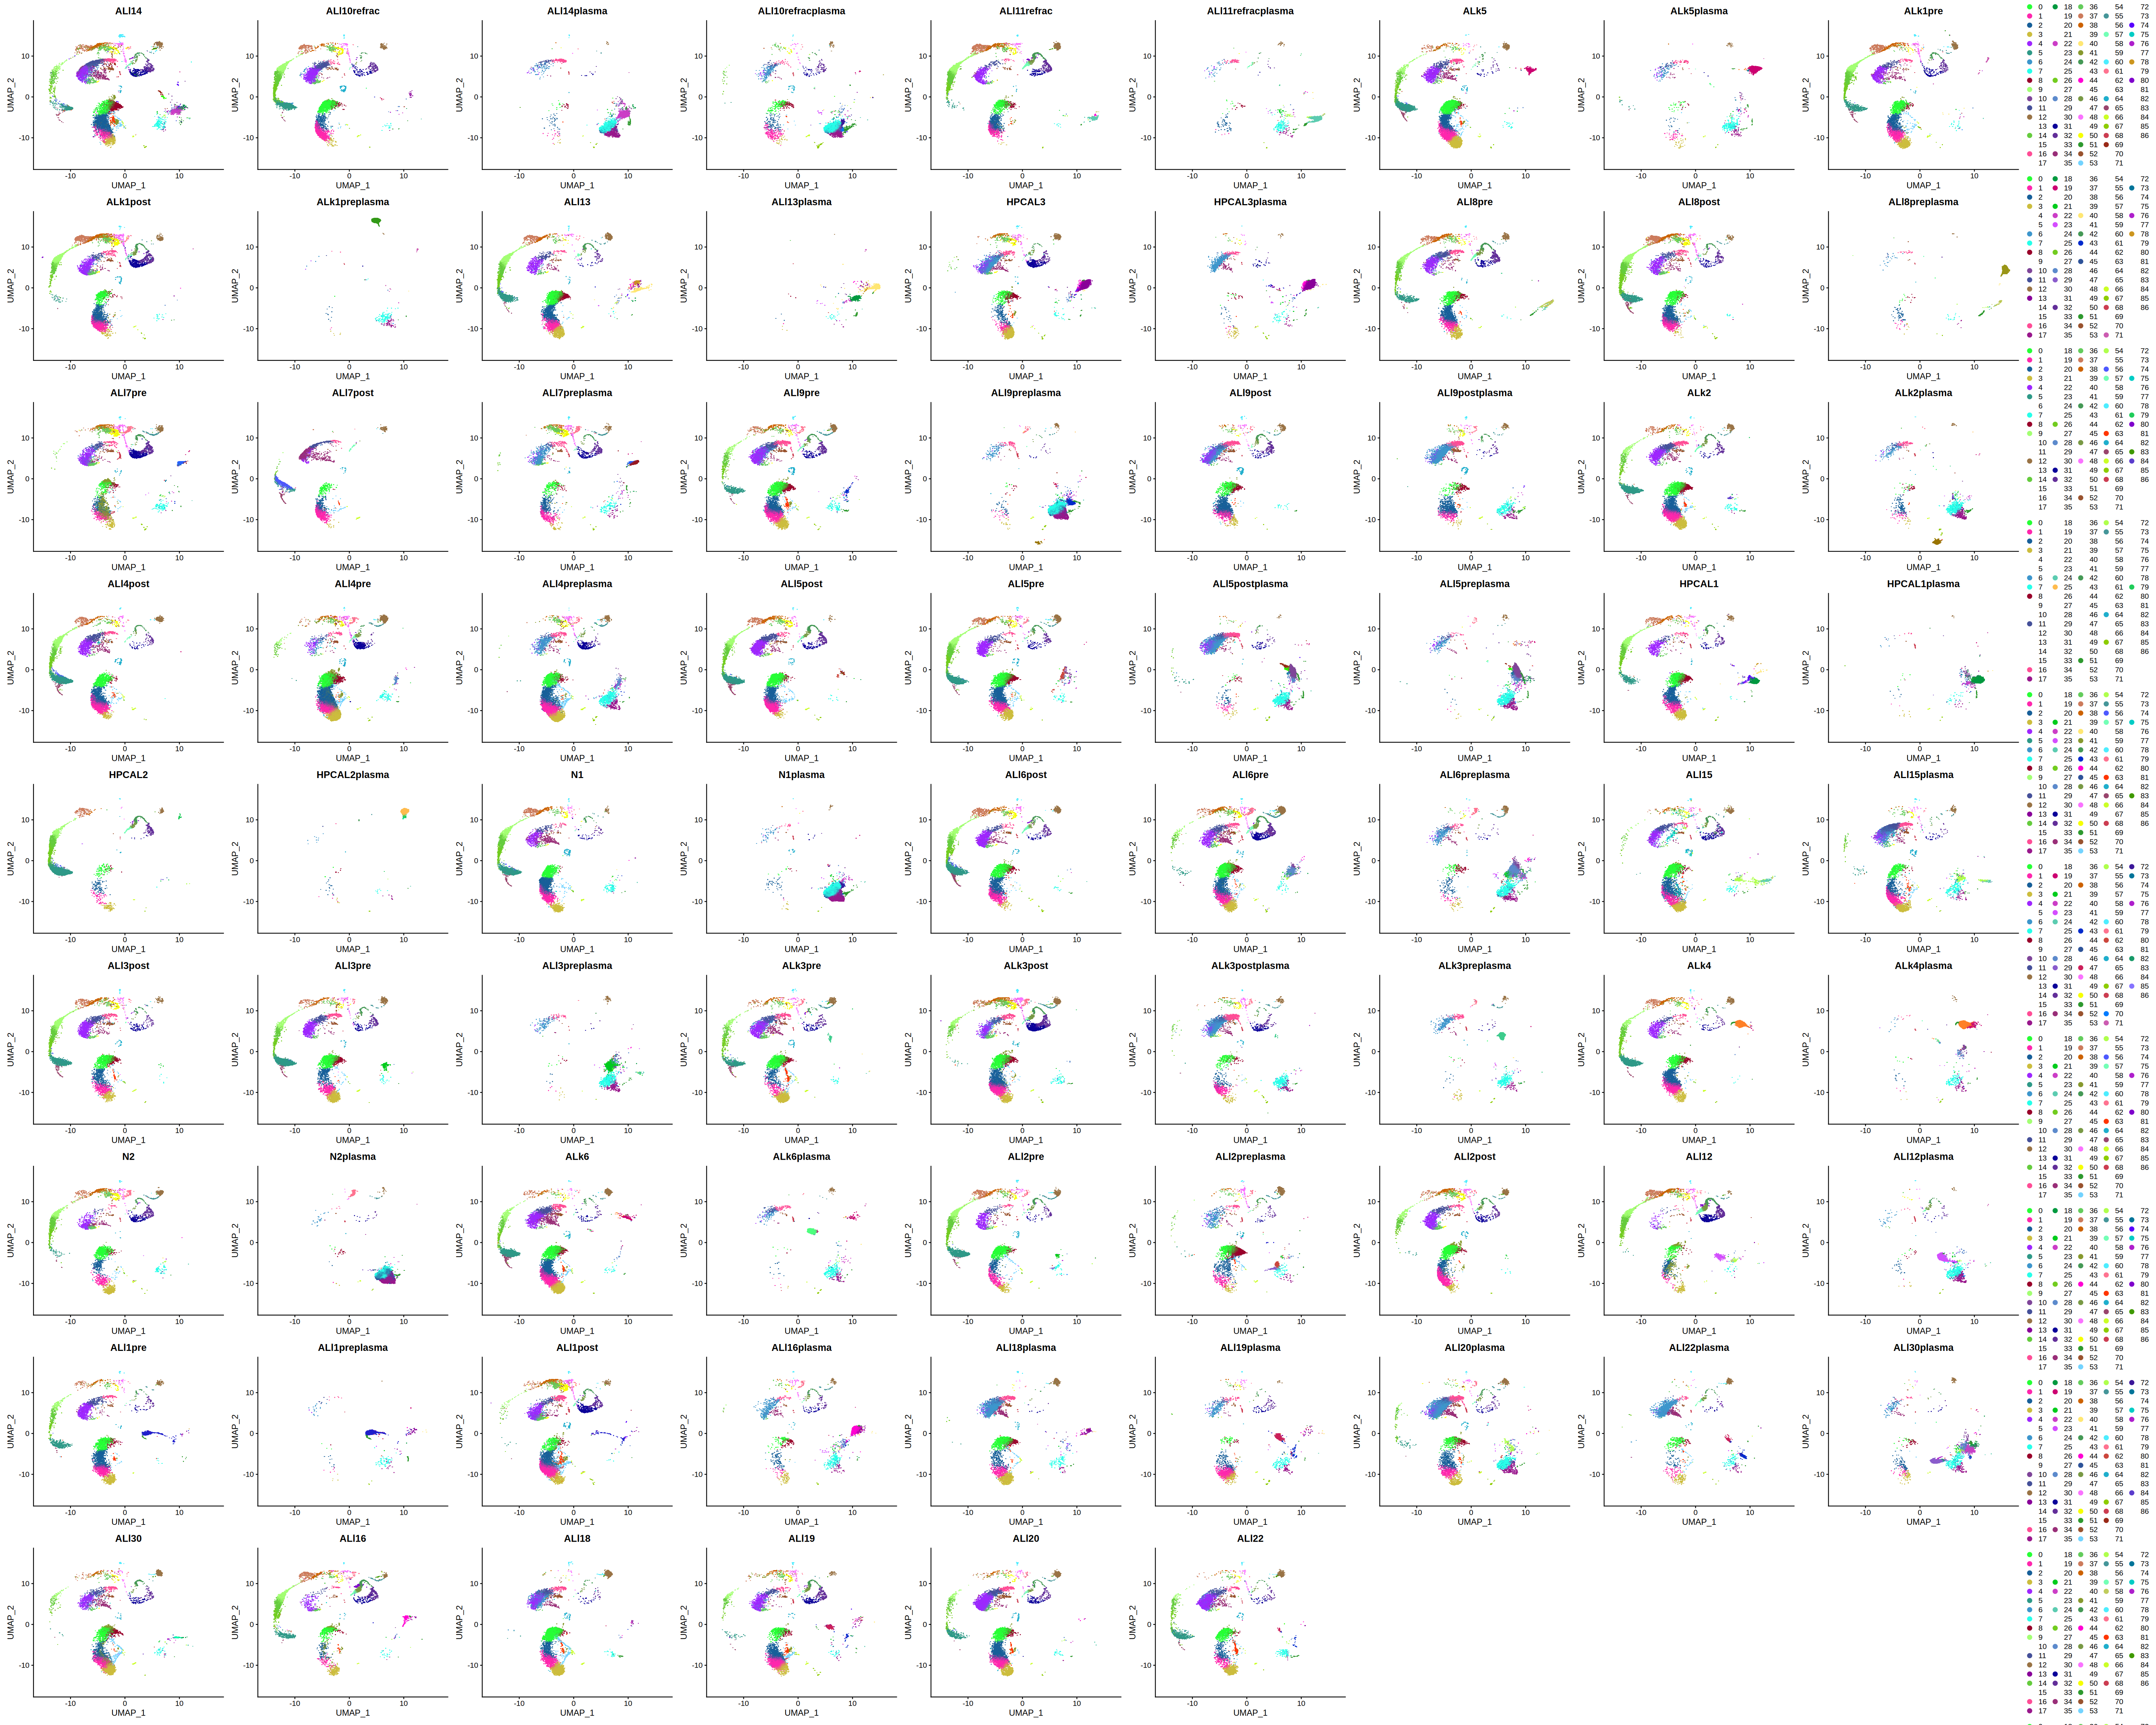

In [8]:
library(scCustomize)
options(repr.plot.height=40,repr.plot.width=50)
DimPlot_scCustom(sce1, pt.size=2,reduction = "UMAP", split.by = c("orig.ident"),label=F) 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



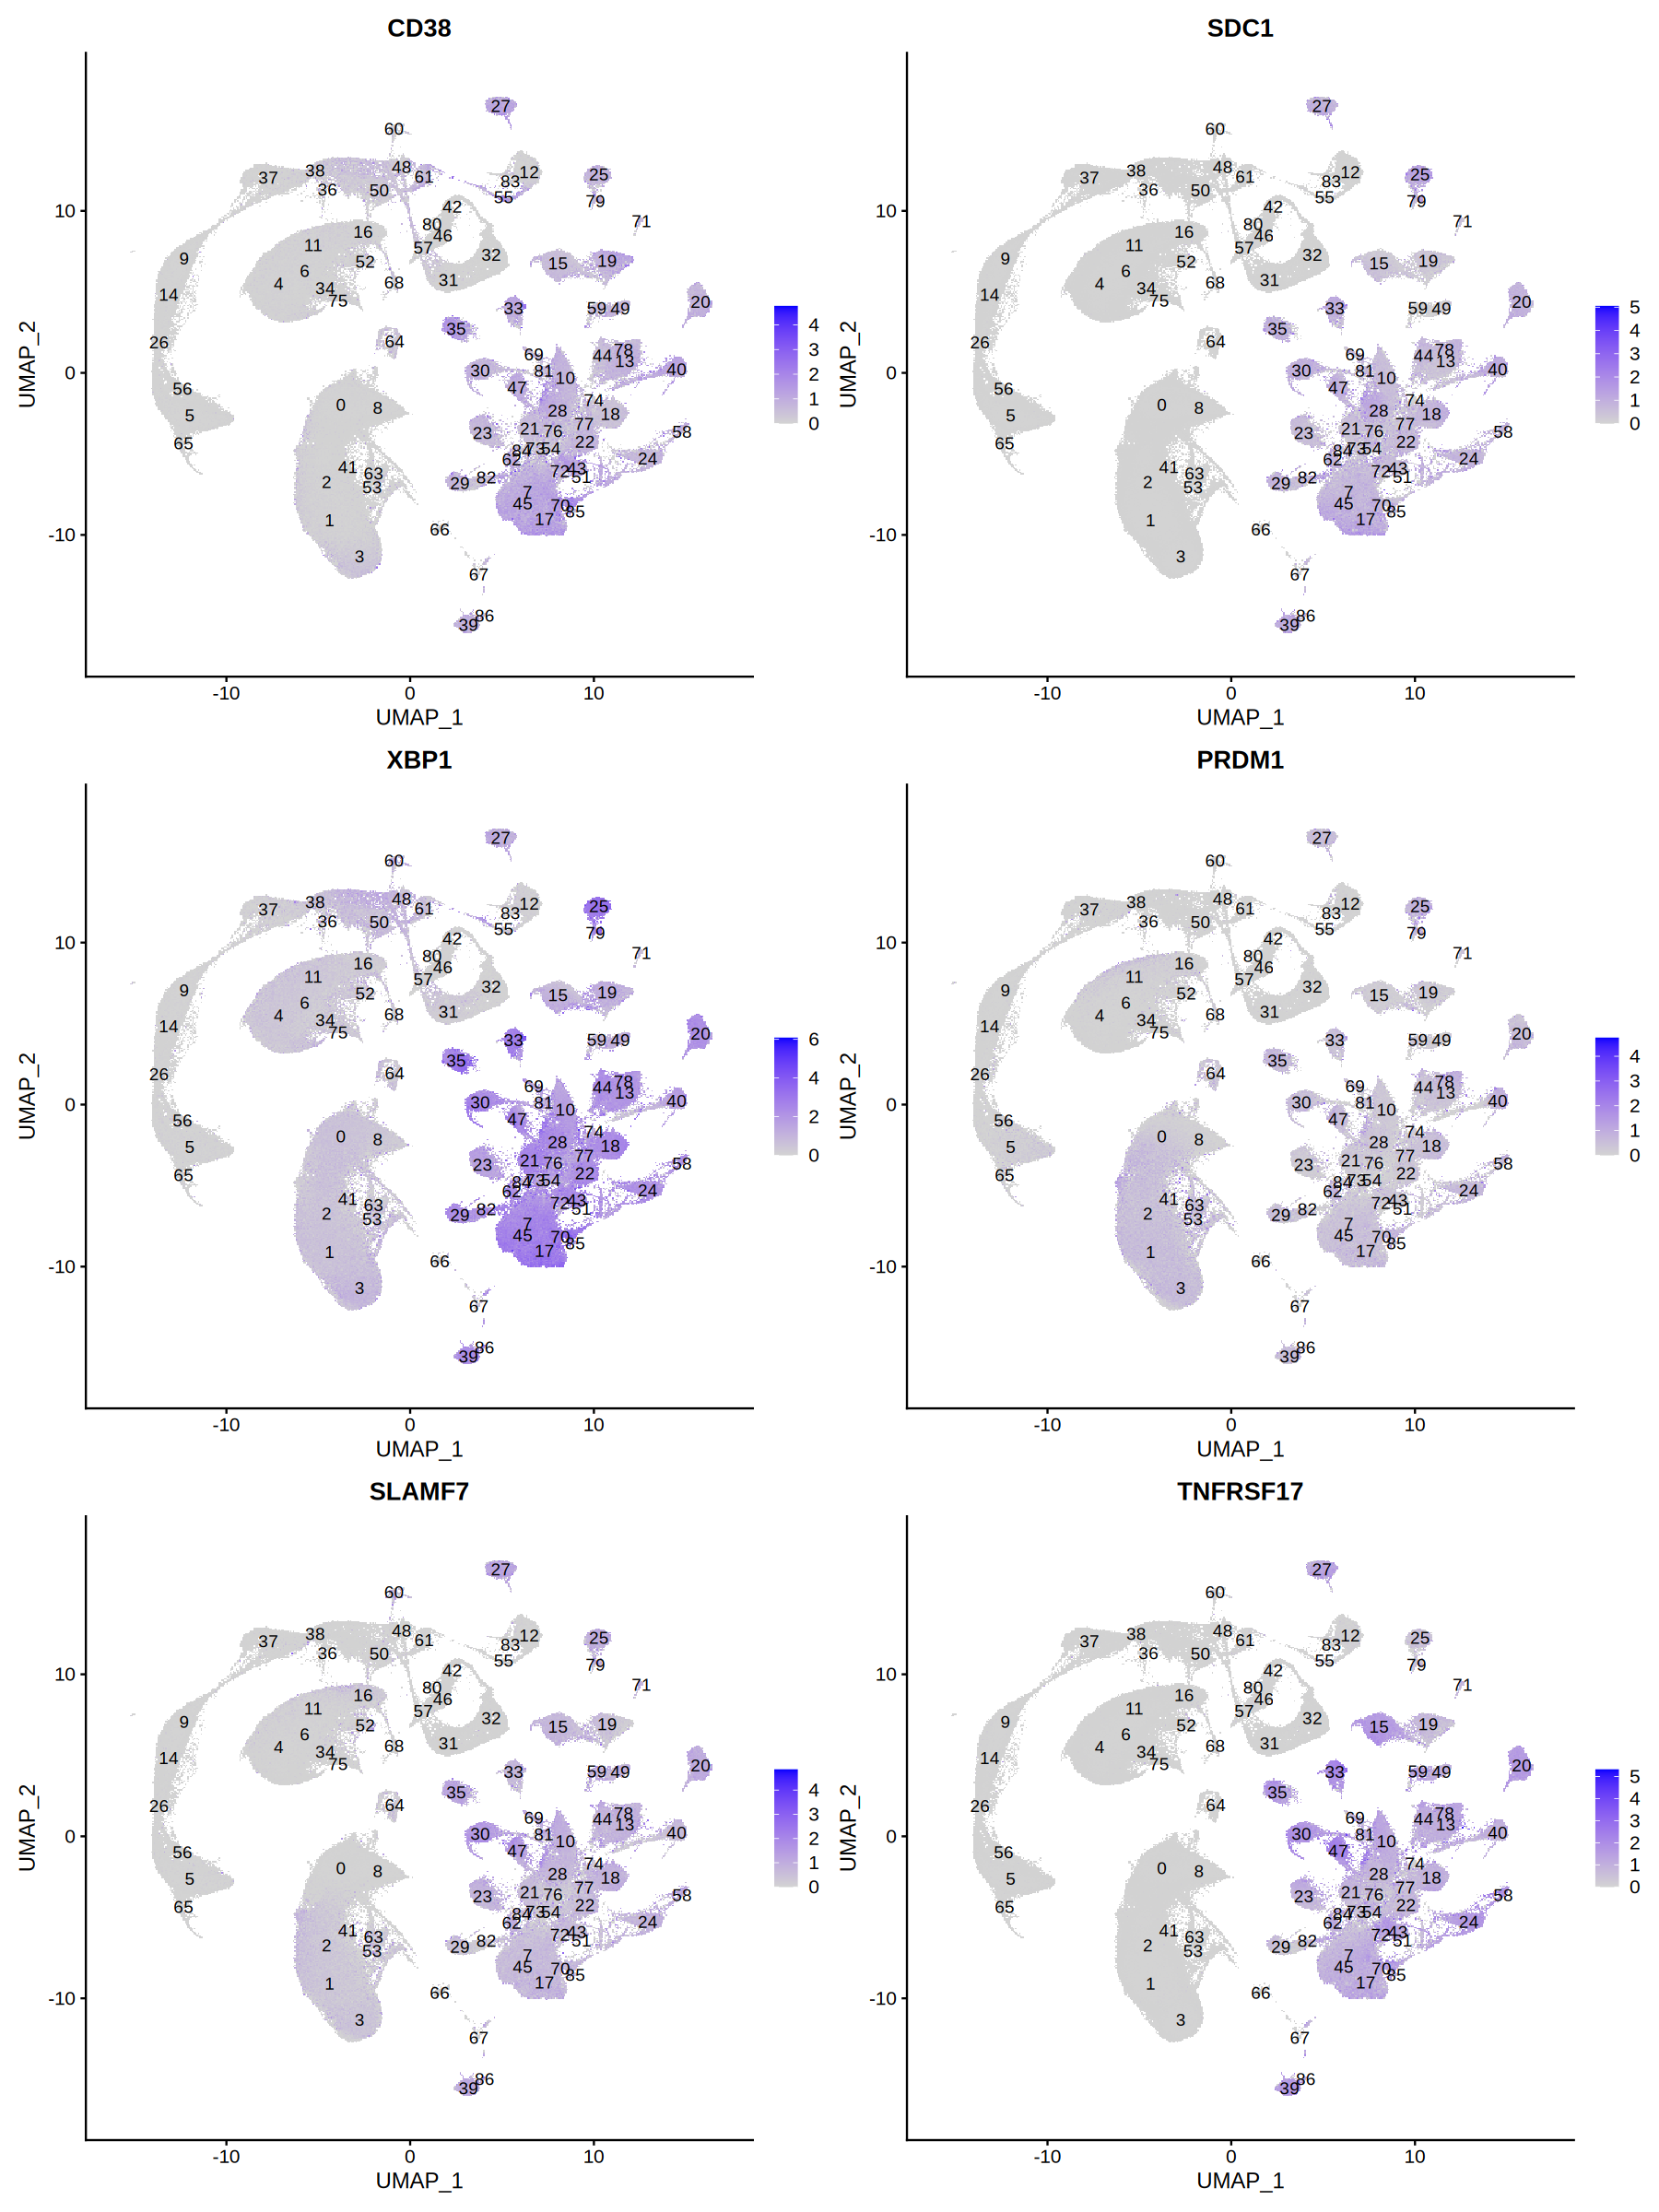

In [9]:
library('RColorBrewer')
options(repr.plot.height=20,repr.plot.width=15)
gene_list_plot <- c("CD38","SDC1",'XBP1','PRDM1','SLAMF7','TNFRSF17')
FeaturePlot(sce1, pt.size=1,reduction = "UMAP", feature = gene_list_plot ,label=T) 

In [10]:
saveRDS(sce1,file='./250817-AL-all78umap-singletonly-umap.rds')

In [11]:
library(Seurat)
library(sceasy)

# Subset both groups together in one step
subset_cells <- sce1

# Ensure RNA assay is properly formatted
subset_cells[["RNA"]] <- as(subset_cells[["RNA"]], "Assay")

# Save as .h5ad
sceasy::convertFormat(subset_cells, from = "seurat", to = "anndata", outFile = "250817-AL-all78umap-singletonly-umap.h5ad")


Loading required package: reticulate

Warning message:
“Assay RNA changing from Assay5 to Assay”
Warning message in .regularise_df(obj@meta.data, drop_single_values = drop_single_values):
“Dropping single category variables:singlet”


AnnData object with n_obs × n_vars = 630111 × 36601
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    obsm: 'X_pca', 'X_umap'